In [1]:
import pandas as pd

df = pd.read_parquet('../data/raw/yellow_tripdata_2025-08.parquet')

In [2]:
df.shape

(3574091, 20)

In [3]:
df.sample(3)

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
789402,2,2025-08-10 01:26:32,2025-08-10 01:53:18,1.0,7.83,1.0,N,79,82,1,37.3,1.0,0.5,5.00,0.00,1.0,48.05,2.5,0.0,0.75
1302716,2,2025-08-15 20:46:35,2025-08-15 21:05:22,1.0,3.89,1.0,N,211,145,1,21.2,1.0,0.5,5.08,6.94,1.0,38.97,2.5,0.0,0.75
2057009,2,2025-08-24 15:00:18,2025-08-24 15:10:11,1.0,1.25,1.0,N,163,170,1,10.0,0.0,0.5,3.00,0.00,1.0,17.75,2.5,0.0,0.75


In [4]:
df.isna().sum()

VendorID                      0
tpep_pickup_datetime          0
tpep_dropoff_datetime         0
passenger_count          886234
trip_distance                 0
RatecodeID               886234
store_and_fwd_flag       886234
PULocationID                  0
DOLocationID                  0
payment_type                  0
fare_amount                   0
extra                         0
mta_tax                       0
tip_amount                    0
tolls_amount                  0
improvement_surcharge         0
total_amount                  0
congestion_surcharge     886234
Airport_fee              886234
cbd_congestion_fee            0
dtype: int64

In [5]:
# ЧАСТЬ 1: ПРОПУСКИ И ДУБЛИКАТЫ
# строки с хотя бы одним NaN — это ровно те же строки, где payment_type == 0

df.index[df.isna().any(axis=1)].equals(df.index[df["payment_type"] == 0])

True

In [6]:
df[df.duplicated()].shape

(0, 20)

In [7]:
# ЧАСТЬ 2: МИНИМАЛЬНАЯ ОЧИСТКА ДАННЫХ
mask_1 = df["tpep_pickup_datetime"] > df["tpep_dropoff_datetime"]
mask_2 = (df["tpep_pickup_datetime"] == df["tpep_dropoff_datetime"]) & (df['trip_distance'] != 0)
mask_3 = (df["tpep_pickup_datetime"] < '2025-08-01') | (df["tpep_pickup_datetime"] >= '2025-09-01')
df[mask_1 | mask_2 | mask_3]

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
2,7,2025-08-01 00:24:38,2025-08-01 00:24:38,2.0,1.89,1.0,N,249,45,1,14.20,0.0,0.5,3.99,0.0,1.0,23.94,2.5,0.0,0.75
3,7,2025-08-01 00:48:19,2025-08-01 00:48:19,1.0,2.35,1.0,N,79,229,1,11.40,0.0,0.5,3.43,0.0,1.0,20.58,2.5,0.0,0.75
23,2,2025-07-31 23:58:11,2025-08-01 00:06:19,1.0,1.51,1.0,N,107,144,1,10.00,1.0,0.5,0.25,0.0,1.0,16.00,2.5,0.0,0.75
92,2,2025-07-31 23:56:03,2025-08-01 00:10:10,1.0,1.91,1.0,N,114,232,1,14.20,1.0,0.5,2.50,0.0,1.0,22.45,2.5,0.0,0.75
139,7,2025-08-01 00:18:29,2025-08-01 00:18:29,1.0,0.98,1.0,N,246,90,2,7.20,0.0,0.5,0.00,0.0,1.0,12.95,2.5,0.0,0.75
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2937622,2,2025-08-09 02:10:00,2025-08-09 02:10:00,NaN,0.01,NaN,None,141,141,0,17.56,0.0,0.5,0.00,0.0,1.0,22.31,NaN,NaN,0.75
2988235,2,2025-08-10 16:11:00,2025-08-10 16:11:00,NaN,0.01,NaN,None,254,254,0,5.57,0.0,0.5,0.00,0.0,1.0,7.07,NaN,NaN,0.00
3097764,2,2025-08-15 01:12:17,2025-08-15 01:12:17,NaN,1.32,NaN,None,129,129,0,-1.50,0.0,0.5,0.00,0.0,1.0,4.00,NaN,NaN,0.00
3247843,2,2025-08-20 13:43:00,2025-08-20 13:43:00,NaN,0.01,NaN,None,239,239,0,11.00,0.0,0.5,3.48,0.0,1.0,18.48,NaN,NaN,0.00


In [8]:
# проблемных строк 46185
# 46185 записей составляют ~1.3% от размера всей выборки, удалим эти записи
df = df[~(mask_1 | mask_2 | mask_3)]

In [9]:
# проверяю PULocationID, DOLocationID
zones = pd.read_csv("../data/raw/taxi_zone_lookup.csv")
valid_ids = set(zones["LocationID"])
print('записей с несуществующими зонами посадки:', df[~(df["PULocationID"].isin(valid_ids))].shape[0])
print('записей с несуществующими зонами высадки:', df[~(df["DOLocationID"].isin(valid_ids))].shape[0])

записей с несуществующими зонами посадки: 0
записей с несуществующими зонами высадки: 0


In [10]:
df[df["PULocationID"] == 264]

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
1028,1,2025-08-01 00:46:25,2025-08-01 01:17:34,1.0,19.00,2.0,N,264,4,1,70.00,3.25,0.5,14.95,0.0,1.0,89.70,2.5,0.0,0.75
1942,1,2025-08-01 00:18:09,2025-08-01 00:41:27,1.0,9.40,3.0,N,264,264,1,58.70,0.00,0.0,11.95,0.0,1.0,71.65,0.0,0.0,0.00
2263,2,2025-08-01 01:07:51,2025-08-01 01:23:55,2.0,2.84,1.0,N,264,164,1,17.00,1.00,0.5,4.55,0.0,1.0,27.30,2.5,0.0,0.75
2887,1,2025-08-01 01:15:48,2025-08-01 01:44:47,1.0,6.40,1.0,N,264,80,1,32.40,4.25,0.5,7.60,0.0,1.0,45.75,2.5,0.0,0.75
3988,1,2025-08-01 02:12:19,2025-08-01 02:21:14,1.0,2.00,1.0,N,264,264,1,12.10,4.25,0.5,1.00,0.0,1.0,18.85,2.5,0.0,0.75
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3546963,2,2025-08-31 05:15:00,2025-08-31 05:48:10,NaN,18.67,NaN,None,264,264,0,57.85,0.00,0.5,14.17,0.0,1.0,76.77,NaN,NaN,0.75
3547484,2,2025-08-31 06:40:31,2025-08-31 06:55:01,NaN,0.00,NaN,None,264,264,0,16.11,0.00,0.5,0.00,0.0,1.0,17.61,NaN,NaN,0.00
3566379,2,2025-08-31 20:58:07,2025-08-31 21:06:22,NaN,2.18,NaN,None,264,264,0,13.31,0.00,0.5,0.00,0.0,1.0,17.31,NaN,NaN,0.00
3567097,2,2025-08-31 20:24:24,2025-08-31 20:42:27,NaN,3.64,NaN,None,264,264,0,18.84,0.00,0.5,0.00,0.0,1.0,20.34,NaN,NaN,0.00


In [13]:
# записей с зоной 264 всего 5377
# Для анализа локального спроса нужна известная зона посадки, поэтому удаляю их.
df = df[df["PULocationID"] != 264]

In [14]:
# ЧАСТЬ 3: EDA
print('удалено записей из таблицы:', 3574091-df.shape[0])
print('осталось записей о поездке:', df.shape[0])
print('максимальная и минимальная даты в таблице:', df['tpep_pickup_datetime'].max(), df['tpep_pickup_datetime'].min())

удалено записей из таблицы: 51562
осталось записей о поездке: 3522529
максимальная и минимальная даты в таблице: 2025-08-31 23:59:59 2025-08-01 00:00:01


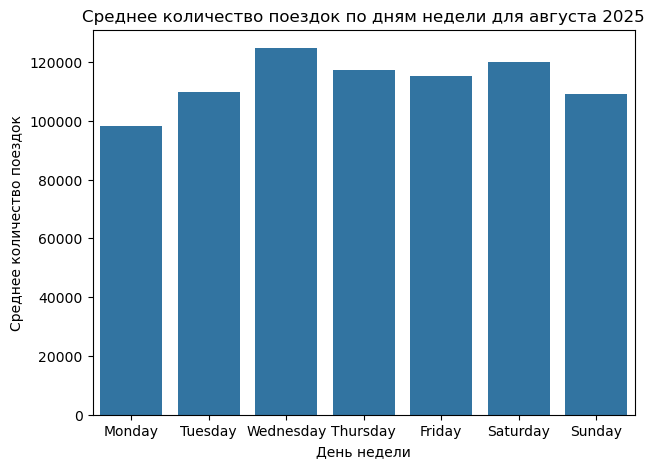

In [15]:
# рассмотрим распределение записей по дням недели (считая для начала поездки) и визуализируем
import seaborn as sns
import matplotlib.pyplot as plt


plt.figure(figsize=(7, 5))
first_group = df.groupby(df['tpep_pickup_datetime'].dt.date).size()
weekday_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]
second_group = first_group.groupby(pd.to_datetime(first_group.index).day_name()).mean()
second_group = second_group.reindex(weekday_order)
sns.barplot(data=second_group).set(title='Среднее количество поездок по дням недели для августа 2025',
                                   xlabel='День недели',
                                   ylabel='Среднее количество поездок');

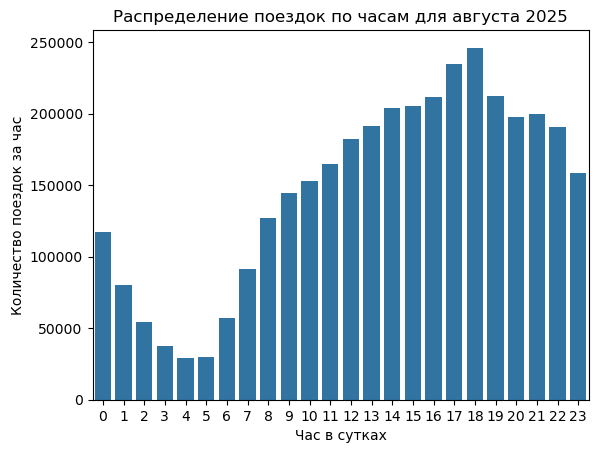

In [16]:
# рассмотрим распределение записей по часам и визуализируем
gr = df.groupby(df['tpep_pickup_datetime'].dt.hour).size()
sns.barplot(data=gr).set(
    title='Распределение поездок по часам для августа 2025', 
    xlabel='Час в сутках', 
    ylabel='Количество поездок за час');

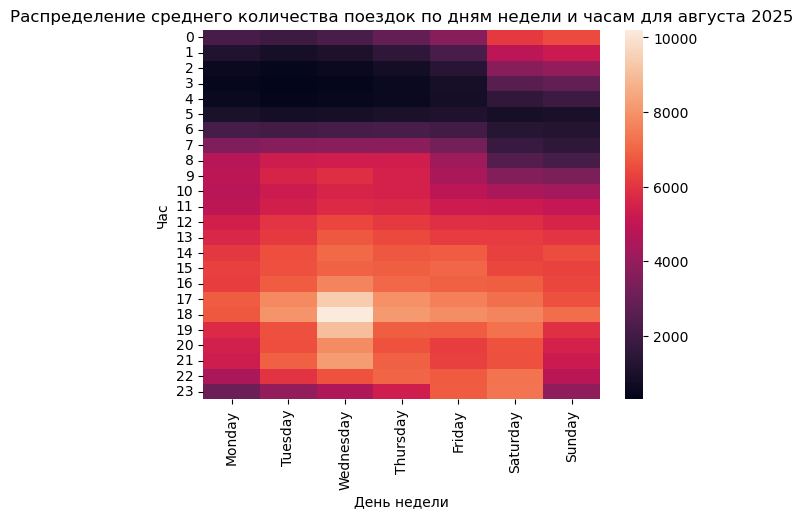

In [17]:
# Посмотрим среднее количество поездок по дню недели и часу
day_hour = df.groupby([
    df["tpep_pickup_datetime"].dt.date.rename("date"), 
    df["tpep_pickup_datetime"].dt.day_name().rename("day_of_week"), 
    df["tpep_pickup_datetime"].dt.hour.rename("hour")]).size().rename("trips")
day_hour = day_hour.reset_index()

day_hour = day_hour.groupby([
    day_hour["day_of_week"],
    day_hour["hour"]])["trips"].mean()
day_hour = day_hour.reset_index()


day_hour = day_hour.pivot(columns="day_of_week", index="hour", values="trips")
day_hour = day_hour[weekday_order]

sns.heatmap(day_hour).set(title="Распределение среднего количества поездок по дням недели и часам для августа 2025", 
                          xlabel="День недели", 
                          ylabel="Час");

In [18]:
# Первые 2 графика распределений не имеют значимых отличий от июльских.
# Хитмап показывает, что самый активный день теперь среда, пик - в 18 часов.

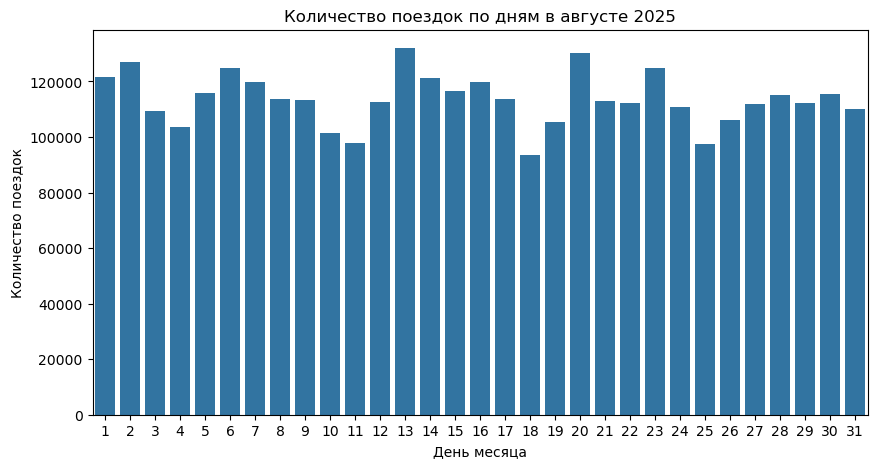

In [19]:
# Рассмотрим спрос на такси в конкретные даты

from datetime import date


gr_date = df.groupby(df["tpep_pickup_datetime"].dt.date.rename("date")).size().rename("trips")
gr_date = gr_date.to_frame()

gr_date = gr_date.reset_index()
gr_date["date"] = pd.to_datetime(gr_date["date"])
gr_date["date"] = gr_date["date"].dt.day

plt.figure(figsize=(10, 5))
sns.barplot(data=gr_date, x="date", y="trips").set(
    title="Количество поездок по дням в августе 2025", 
    xlabel="День месяца", 
    ylabel="Количество поездок");

# Паттерн прошлых месяцев сохраняется.
# Особенно низкие значения наблюдаются по понедельникам: 4, 11, 18, 25 августа.

In [20]:
# Зона посадки PULocationID

start_zone_borough = df.groupby(df["PULocationID"]).size().rename("trips")
start_zone_borough = start_zone_borough.to_frame()
start_zone_borough = start_zone_borough.merge(zones[["LocationID", "Borough", "Zone"]], left_index=True, right_on='LocationID')
start_zone_borough = start_zone_borough.set_index("LocationID")
start_borough = start_zone_borough.groupby(start_zone_borough["Borough"])["trips"].sum().sort_values()
start_borough = start_borough.to_frame()
start_borough
# ожидаемо, поездки на жёлтых такси всё так же преобладают на Манхэттене

,trips
Borough,
Staten Island,356
EWR,559
Bronx,31902
Brooklyn,166627
Queens,409469
Manhattan,2911400


In [21]:
# ЧАСТЬ 4: ИСКОМЫЕ ДАННЫЕ
venue_zone_ids = [79, 161, 163, 186, 239]

df_selected = df[
    df["PULocationID"].isin(venue_zone_ids)
]

data_pickup = (
    df_selected
    .groupby([
        df_selected["tpep_pickup_datetime"].dt.floor("D").rename("date"),
        df_selected["tpep_pickup_datetime"].dt.hour.rename("hour"),
        df_selected["PULocationID"].rename("LocationID")
    ])
    .size()
    .rename("pickups")
    .reset_index()
)

data_pickup

,date,hour,LocationID,pickups
0,2025-08-01,0,79,180
1,2025-08-01,0,161,96
2,2025-08-01,0,163,63
3,2025-08-01,0,186,77
4,2025-08-01,0,239,33
...,...,...,...,...
3711,2025-08-31,23,79,212
3712,2025-08-31,23,161,93
3713,2025-08-31,23,163,64
3714,2025-08-31,23,186,290


In [22]:
# В таблице должно быть 31 дней x 24 часа x 5 зон = 3720 записей, сейчас в таблице 3716 записей.

full_index = pd.MultiIndex.from_product(
    [
        pd.date_range("2025-08-01", "2025-08-31", freq="D"),
        range(24),
        venue_zone_ids
    ],
    names=["date", "hour", "LocationID"]
)

data_pickup = (
    data_pickup
    .set_index(["date", "hour", "LocationID"])
    .reindex(full_index, fill_value=0)
    .reset_index()
)

assert (
    data_pickup["pickups"].sum()
    ==
    df["PULocationID"].isin(venue_zone_ids).sum()
)

data_pickup

,date,hour,LocationID,pickups
0,2025-08-01,0,79,180
1,2025-08-01,0,161,96
2,2025-08-01,0,163,63
3,2025-08-01,0,186,77
4,2025-08-01,0,239,33
...,...,...,...,...
3715,2025-08-31,23,79,212
3716,2025-08-31,23,161,93
3717,2025-08-31,23,163,64
3718,2025-08-31,23,186,290


In [23]:
# ЧАСТЬ 5: СОХРАНЕНИЕ ОБРАБОТАННЫХ ДАННЫХ

from pathlib import Path

processed_taxi_dir = Path("../data/processed/taxi")
processed_taxi_dir.mkdir(parents=True, exist_ok=True)

output_path = (
    processed_taxi_dir
    / "yellow_taxi_pickups_2025_08.parquet"
)

data_pickup.to_parquet(
    output_path,
    index=False
)

In [24]:
data_pickup_check = pd.read_parquet(output_path)

print("Размер:", data_pickup_check.shape)
print(
    "Дубликаты:",
    data_pickup_check.duplicated(
        subset=["date", "hour", "LocationID"]
    ).sum()
)
print("Пропуски:", data_pickup_check.isna().sum().sum())
print("Количество зон:", data_pickup_check["LocationID"].nunique())

assert data_pickup_check.equals(data_pickup)

Размер: (3720, 4)
Дубликаты: 0
Пропуски: 0
Количество зон: 5
